In [1]:
# 3-level SDAE on MNIST dataset, BCELoss. Декодер через sigmoid

# @launchit.collected

In [2]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

import sys
import os
from collections import namedtuple # @launchit.collect
from pathlib import Path
import json
import datetime
import pprint
from functools import cache
import re
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets

sys.path.append(project_root_path)
from lib.utils import *
from lib.logging import *
from lib.model_registry import *
import lib.launchit # @launchit.disable

2026-01-13 09:35:21.427346: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-13 09:35:21.463503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 09:35:22.257532: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Setup

In [3]:
LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, data_path, mnist_path, metrics_path, ' + 
                    'notebook_fname, notebook_name, is_cuda, cuda_device, is_launch')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    metrics_path=os.path.expanduser('~/tensorboard'),
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    is_launch=False,
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=notebook_name, is_launch=not re.match(r'\w+-launch\d+$', notebook_name) is None)

print('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
print('')

# @launchit.disable
# @launchit.collect
MODEL_INSTANCE_INFO = namedtuple('ModelInstanceInfo', 'group_uri, name, version, main_asset_fname')(
    group_uri='${MODEL_GROUP_URI}',
    name='${MODEL_NAME}',
    version=0,
    main_asset_fname='${LAUNCHIT_FNAME}'
)
# @launchit.stop

MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(group_uri=f'{CONFIG.project_root_uri}.{os.path.basename(os.path.dirname(notebook_fname))}')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(name=CONFIG.notebook_name)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(main_asset_fname=CONFIG.notebook_fname)
# @launchit.stop

print('MODEL_INSTANCE_INFO=\n' + pprint.pformat(MODEL_INSTANCE_INFO._asdict()))

MODEL_REGISTRY = ModelRegistry(MODEL_INSTANCE_INFO.group_uri)

CONFIG=
{'cuda_device': 'cpu',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'is_cuda': False,
 'is_launch': False,
 'metrics_path': '/home/misha/tensorboard',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'notebook_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_06.ipynb',
 'notebook_name': 's3_stacked_dae_06',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision'}

MODEL_INSTANCE_INFO=
{'group_uri': 'com.develorium.neurovision.denoise',
 'main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_06.ipynb',
 'name': 's3_stacked_dae_06',
 'version': 0}


# Launchit

In [4]:
# @launchit.disable
launchit_t0 = time.time()

In [5]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    expandvars = dict(
        MODEL_GROUP_URI=MODEL_INSTANCE_INFO.group_uri,
        MODEL_NAME=MODEL_INSTANCE_INFO.name,
    )
    lib.launchit.launchit(CONFIG.notebook_fname, expandvars)
else:
    print('Skip launchit due to mass "Run Cells"')

Skip launchit due to mass "Run Cells"


# Hypers

In [6]:
# @launchit.disable
# @launchit.collect
HP = namedtuple('HyperParameters', [
    'dataset_preprocessing',
    'noise',
    'daes_count',
    'filters_count',
    'batch_size',
    'trained_dae_inds',
    'epochs_count',
    'loss',
    'is_tied_weights',
    'optimizer',
    'learn_rate', 
], defaults=[None] * 11)()

# Dataset

In [7]:
# @launchit.disable
# @launchit.collect
HP = HP._replace(
    dataset_preprocessing='NONE', # NONE, UNINORM, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
)

## get_mnist_data

In [8]:
def get_mnist_data(is_train):
    d = datasets.MNIST(CONFIG.mnist_path, train=is_train, download=True)
    images = d.data.reshape(len(d.data), -1)
    images = images.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [9]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## preprocess_images

In [10]:
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

# Noising

## gauss_noise

In [11]:
def gauss_noise(items, gadds_tab):
    if items.ndim == 2:
        assert items.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {gadds_tab.shape[1]}'
        items_count = len(items)
        noise = gadds_tab[RNG.choice(len(gadds_tab), items_count)]
    elif items.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        return items + noise
    elif isinstance(items, torch.Tensor):
        return items + torch.tensor(noise, device=items.device, dtype=items.dtype)

## masking_noise

In [12]:
def masking_noise(items, masks_tab, fill_value=0):
    if items.ndim == 2:
        assert items.shape[1] == masks_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {masks_tab.shape[1]}'
        items_count = len(items)
        mask_inds = RNG.choice(len(masks_tab), items_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif items.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        noised = items.copy()
    elif isinstance(items, torch.Tensor):
        noised = items.clone()
    else:
        assert False, f'Unsupported type(items): {type(items)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [13]:
def generate_zmasks(ν, item_size, count):
    assert 0 <= ν <= 1
    zero_inds_count = int(ν * item_size)
    zmasks = np.full((count, item_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(item_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

## Demo

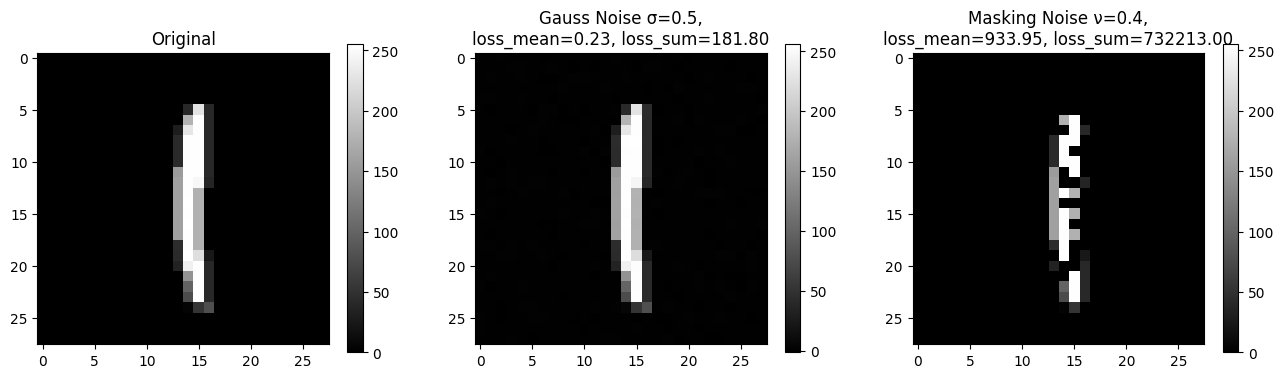

In [14]:
# @launchit.disable
images, _ = get_mnist_data(is_train=True)
images, _ = preprocess_images(images, HP.dataset_preprocessing)
image_ind = RNG.choice(len(images))
image = images[image_ind]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original')
im = ax1.imshow(vec_to_square_matrix(image), cmap='gray');
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, image.shape[0]))
noised = gauss_noise(image.ravel(), gadds)
noised = noised.reshape(image.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax2.imshow(vec_to_square_matrix(noised), cmap='gray');
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(ν, image.shape[0], 100)
noised = masking_noise(image.ravel(), zmasks, fill_value=0)
noised = noised.reshape(image.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax3.imshow(vec_to_square_matrix(noised), cmap='gray');
fig.colorbar(im, ax=ax3, shrink=.5);

# Unsupervised

## Dataset

In [15]:
images, _ = get_mnist_data(is_train=True)
images, _ = preprocess_images(images, HP.dataset_preprocessing)
DATASET = torch.Tensor(images)
DATASET = DATASET.contiguous() # force dense memory layout (speeds up DataLoader x2)

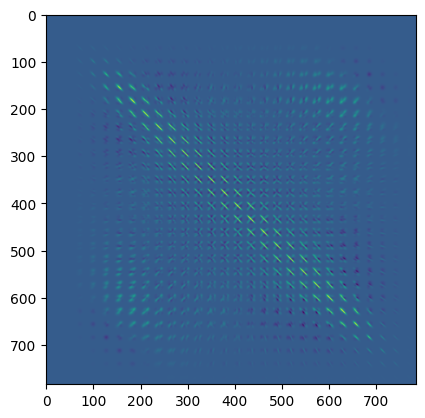

In [16]:
# @launchit.disable
plt.imshow(np.cov(DATASET, rowvar=False));

## Model

In [17]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count, is_tied_weights):
        super().__init__()
        self.encoder = tnn.Linear(inp_dims_count, hiddens_count) # aka filters
        bound = 1 / np.sqrt(inp_dims_count)
        self.encoder.weight.data.uniform_(-bound, bound)
        
        self.is_tied_weights = is_tied_weights

        if is_tied_weights:
            self.decoder_bias = tnn.Parameter(torch.randn(inp_dims_count))
        else:
            self.decoder = tnn.Linear(hiddens_count, inp_dims_count)
            bound = 1 / np.sqrt(hiddens_count)
            self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        encoded = self.encode(inp)
        decoded = self.decode(encoded)
        return decoded

    def encode(self, inp):
        return tnnf.sigmoid(self.encoder(inp))

    def decode(self, inp):
        if self.is_tied_weights:
            res = tnnf.linear(inp, self.encoder.weight.t(), self.decoder_bias)
            return tnnf.sigmoid(res) 
        else:
            return tnnf.sigmoid(self.decoder(inp)) 

class StackedDAE(tnn.Module):
    def __init__(self, daes_count, inp_dims_count, hiddens_count, is_tied_weights):
        super().__init__()
        self.daes = tnn.ModuleList()

        current_inp_dims_count = inp_dims_count
        
        for i in range(daes_count):
            dae = DenoiseAutoencoder(current_inp_dims_count, hiddens_count, is_tied_weights)
            current_inp_dims_count = hiddens_count
            self.daes.append(dae)

    def encode(self, inp, daes_count=-1):
        daes_count = len(self.daes) if daes_count == -1 else daes_count
        
        for i in range(0, daes_count):
            dae = self.daes[i]
            inp = dae.encode(inp)

        return inp

In [18]:
model = StackedDAE(1, DATASET.shape[1], 1000, is_tied_weights=True)
sum([p.numel() for p in model.parameters()])

785784

In [19]:
data_loader = DataLoader(DATASET, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(model.daes)):
        save_shape = batch.shape
        batch = model.daes[i].encode(batch)
        print(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(model.daes))):
        save_shape = batch.shape
        batch = model.daes[i].decode(batch)
        print(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 784])->torch.Size([100, 1000])
Decoding by DAE_0, batch shape=torch.Size([100, 1000])->torch.Size([100, 784])


## Training

In [20]:
@cache
def gadds(σ, item_size, gadds_count):
    return RNG.normal(0, σ, (gadds_count, item_size)).astype(float) 

@cache
def zmasks(ν, item_size, masks_count):
    return generate_zmasks(ν, item_size, masks_count)

In [21]:
noise_funcs = {
    'Gauss_0.5': lambda items: gauss_noise(items, gadds(0.5, items.shape[1], 250_000)),
    'Masking_0': lambda items: masking_noise(items, zmasks(0, items.shape[1], 250_000)),
    'Masking_0.1': lambda items: masking_noise(items, zmasks(0.1, items.shape[1], 250_000)),
    'Masking_0.25': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000)),
    'Masking_0.25_1': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000), fill_value=1),
    'Masking_0.3': lambda items: masking_noise(items, zmasks(0.3, items.shape[1], 250_000)),
    'Masking_0.4': lambda items: masking_noise(items, zmasks(0.4, items.shape[1], 250_000)),
    'Masking_0.55': lambda items: masking_noise(items, zmasks(0.55, items.shape[1], 250_000)),
}

losses = {
    # sigmoid is expected to be withing Model structure (decoder)
    'BCE_mean': lambda: tnn.BCELoss(reduction='mean'), 
    'BCE_sum': lambda: tnn.BCELoss(reduction='sum'),
    # sigmoid is builtin into loss itself
    'BCEWithLogits_mean': lambda: tnn.BCEWithLogitsLoss(reduction='mean'), 
    'BCEWithLogits_sum': lambda: tnn.BCEithLogitsLoss(reduction='sum'),
    'MSE': lambda: tnn.MSELoss(),
}

optimizers = {
    'SGD': lambda parameters, lr: topt.SGD(parameters, lr),
    'Adam': lambda parameters, lr: topt.Adam(parameters, lr),
}

# @launchit.disable
# @launchit.collect
HP = HP._replace(
    daes_count=3,
    filters_count=1_000,
    batch_size=1_000,
    epochs_count=500,
    noise='Masking_0.4',
    loss='BCE_mean',
    is_tied_weights=True,
    learn_rate=0.05,
    optimizer='Adam',
)
HP = HP._replace(
    trained_dae_inds=','.join(map(str, range(HP.daes_count)))
)
# @launchit.stop
pprint.pprint(HP._asdict())

{'batch_size': 1000,
 'daes_count': 3,
 'dataset_preprocessing': 'NONE',
 'epochs_count': 500,
 'filters_count': 1000,
 'is_tied_weights': True,
 'learn_rate': 0.05,
 'loss': 'BCE_mean',
 'noise': 'Masking_0.4',
 'optimizer': 'Adam',
 'trained_dae_inds': '0,1,2'}


In [ ]:
data_loader = DataLoader(DATASET, batch_size=HP.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
model = StackedDAE(HP.daes_count, DATASET.shape[1], HP.filters_count, HP.is_tied_weights)
model = model.to(device=CONFIG.cuda_device)
optimizer = optimizers[HP.optimizer](model.parameters(), lr=HP.learn_rate)
loss_fn = losses[HP.loss]()
epoch = 0

# MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=18)

if MODEL_INSTANCE_INFO.version == 0:
    new_model_instance_version = MODEL_REGISTRY.register_model(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.main_asset_fname)
    MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=new_model_instance_version)
    print(f'Model instance registered, version={MODEL_INSTANCE_INFO.version}')
else:
    pt_data = MODEL_REGISTRY.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pt')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = int(checkpoint['epoch'])
    print(f'Model instance loaded from version={MODEL_INSTANCE_INFO.version}, epoch={epoch}')

metrics_dir = os.path.join(CONFIG.metrics_path, MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))
metrics_writer = SummaryWriter(log_dir=metrics_dir)
metrics_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
metrics_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)
print(f'metrics_dir={metrics_dir}')

In [ ]:
example_item_ind = RNG.choice(len(DATASET))
model.train()

for trained_dae_ind in tqdm(list(map(int, HP.trained_dae_inds.split(','))), 'DAE'):
    noise_func = noise_funcs[HP.noise]
    
    for epoch in tqdm(range(epoch + 1, epoch + HP.epochs_count + 1), 'Epoch'):
        loss_train = 0
        
        for batch in data_loader:
            optimizer.zero_grad()
            
            inp = batch.to(device=CONFIG.cuda_device)
    
            with torch.no_grad():
                assert 0 <= trained_dae_ind < len(model.daes)
    
                for i in range(0, trained_dae_ind):
                    inp = model.daes[i].encode(inp)
    
            trained_dae = model.daes[trained_dae_ind]
            noised_inp = noise_func(inp)
            out = trained_dae(noised_inp)
    
            loss = loss_fn(out, inp) # args order: input, target
            loss.backward()
            
            optimizer.step()
            
            loss_train += loss.item()
        
        metrics_writer.add_scalar('loss', loss_train / len(data_loader), epoch)
    
        if (epoch % 20) == 0:
            # Examples -> tensorboard
            if len(model.daes) > 1:
                fig, axes = plt.subplots(len(model.daes) * 3, 1, subplot_kw={'yticks': []})
            else:
                fig, axes = plt.subplots(1, len(model.daes) * 3, subplot_kw={'yticks': []})
                
            axes = axes.ravel()
            fig.set_figwidth(18)
            fig.set_figheight(3 * 4)
            
            with torch.no_grad():
                for target_dae_ind, base_ax_ind in zip(range(len(model.daes)), range(len(axes))[::3]):
                    batch = DATASET[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                
                    for i in range(target_dae_ind):
                        batch = model.daes[i].encode(batch)
            
                    noised = noise_func(batch)
                    reconstructed = model.daes[target_dae_ind](noised)
                    reconstructed = reconstructed.to(device='cpu').detach()
                    noised = noised.to(device='cpu').detach()
            
                    ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

                    batch = batch.to(device='cpu')
                    ax1.set_title(f'DAE {target_dae_ind}, Noised loss={loss_fn(noised, batch):.3f}, Reconstr. loss={loss_fn(reconstructed, batch):.3f}')

                    if len(model.daes) > 1:
                        ax1.imshow(np.ones((100, 1)) * batch.numpy().ravel(), aspect='auto')
                        ax2.imshow(np.ones((100, 1)) * noised.numpy().ravel(), aspect='auto')
                        ax3.imshow(np.ones((100, 1)) * reconstructed.numpy().ravel(), aspect='auto')
                    else:
                        im = ax1.imshow(vec_to_square_matrix(batch.numpy().ravel()))
                        fig.colorbar(im, ax=ax1, shrink=0.4)
                        im = ax2.imshow(vec_to_square_matrix(noised.numpy().ravel()))
                        fig.colorbar(im, ax=ax2, shrink=0.4)
                        im = ax3.imshow(vec_to_square_matrix(reconstructed.numpy().ravel()))
                        fig.colorbar(im, ax=ax3, shrink=0.4)
        
            fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Image #{example_item_ind}');
            fig.tight_layout()
            
            metrics_writer.add_figure('example', fig, epoch, close=True)
            
            # Filters (first DAE only) -> tensorboard
            bases_in_row = 10
            max_filters_to_show = 200
            fig, axes = plt.subplots(int(np.ceil(min(max_filters_to_show, HP.filters_count) / bases_in_row)), bases_in_row)
            fig.set_figwidth(12)
            fig.set_figheight(18)
            filters = model.daes[0].encoder.weight.to(device='cpu').detach()
            
            for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                ax.imshow(vec_to_square_matrix(f), cmap='gray')
                ax.set_xticks([])
                ax.set_yticks([])
            
            fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
            fig.tight_layout()
            
            metrics_writer.add_figure('filters', fig, epoch, close=True)
        
        metrics_writer.flush()

In [ ]:
meta = dict(epoch=epoch, hypers=HP._asdict(), config=CONFIG._asdict())

with io.StringIO() as b:
    json.dump(meta, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'meta', replace=True)

with io.BytesIO() as b:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'pt', replace=True)

In [ ]:
# @launchit.disable
if len(model.daes) > 1:
    fig, axes = plt.subplots(len(model.daes) * 3, 1, subplot_kw={'yticks': []})
else:
    fig, axes = plt.subplots(1, len(model.daes) * 3, subplot_kw={'yticks': []})
    
axes = axes.ravel()
fig.set_figwidth(18)
fig.set_figheight(3 * 4)

example_item_ind = RNG.choice(len(DATASET))
noise_func = noise_funcs[HP.noise]
model.eval()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(model.daes)), range(len(axes))[::3]):
        batch = DATASET[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = model.daes[i].encode(batch)

        noised = noise_func(batch)
        reconstructed = model.daes[target_dae_ind](noised)
        reconstructed = reconstructed.to(device='cpu').detach()
        noised = noised.to(device='cpu').detach()

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

        batch = batch.to(device='cpu')
        ax1.set_title(f'DAE {target_dae_ind}, Noised loss={loss_fn(noised, batch):.3f}, Reconstr. loss={loss_fn(reconstructed, batch):.3f}')

        if len(model.daes) > 1:
            ax1.imshow(np.ones((100, 1)) * batch.numpy().ravel(), aspect='auto')
            ax2.imshow(np.ones((100, 1)) * noised.numpy().ravel(), aspect='auto')
            ax3.imshow(np.ones((100, 1)) * reconstructed.numpy().ravel(), aspect='auto')
        else:
            im = ax1.imshow(vec_to_square_matrix(batch.numpy().ravel()))
            fig.colorbar(im, ax=ax1, shrink=0.4)
            im = ax2.imshow(vec_to_square_matrix(noised.numpy().ravel()))
            fig.colorbar(im, ax=ax2, shrink=0.4)
            im = ax3.imshow(vec_to_square_matrix(reconstructed.numpy().ravel()))
            fig.colorbar(im, ax=ax3, shrink=0.4)
        
fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Image #{example_item_ind}');
fig.tight_layout()

In [ ]:
# @launchit.disable
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = model.encoder.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(f), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
plt.tight_layout()

# Supervised (clasification)

## Pretrained model

In [25]:
# @launchit.disable
train_images, _ = get_mnist_data(is_train=True)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=2)
meta = json.load(io.BytesIO(MODEL_REGISTRY.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'meta')))
HP = HP._replace(**meta['hypers'])
pprint.pprint(HP._asdict())
model = StackedDAE(HP.daes_count, train_images.shape[1], HP.filters_count, HP.is_tied_weights)
model = model.to(device=CONFIG.cuda_device)
pt_data = MODEL_REGISTRY.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pt')
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

{'batch_size': 1000,
 'daes_count': 3,
 'dataset_preprocessing': 'UNINORM',
 'epochs_count': 500,
 'filters_count': 1000,
 'is_tied_weights': True,
 'learn_rate': 0.01,
 'loss': 'BCE_mean',
 'noise': 'Masking_0.4',
 'optimizer': 'Adam',
 'trained_dae_inds': '0,1,2'}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)

## Dataset

In [26]:
# @launchit.disable
def create_dataset_for_classification(images, image_labels):
    features_list = []
    labels_list = []
    assert len(images) == len(image_labels)
    data_loader = DataLoader(list(zip(torch.Tensor(images), image_labels)), batch_size=100)
    
    for images, labels in tqdm(data_loader):
        images = torch.Tensor(images).to(device=CONFIG.cuda_device)
        
        with torch.no_grad():
            features = model.encode(images)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    x = np.vstack(features_list).astype('float64') # float64 is recommended for SVC
    y = np.hstack(labels_list)
    return x, y

In [27]:
# @launchit.disable
train_images, train_image_labels = get_mnist_data(is_train=True)
train_images, train_images_scaler = preprocess_images(train_images, HP.dataset_preprocessing)
x_train, y_train = create_dataset_for_classification(train_images, train_image_labels)

  0%|          | 0/600 [00:00<?, ?it/s]

## SVC

In [42]:
%%time
random_state = 8231
# @launchit.disable

# ПРОВЕРИТЬ НА 6-ой версии!

# parameters = {'C': np.linspace(0.01, 1, 10), 'penalty': ['l1', 'l2'], max_iter=300, random_state=random_state}
# search_svm = GridSearchCV(LinearSVC(max_iter=300), parameters, n_jobs=-1)

# parameters = {'C': np.linspace(0.01, 1, 10), 'kernel': ['linear', 'rbf'], max_iter=300, random_state=random_state}
# parameters = {'C': np.linspace(1, 5, 10), 'kernel': ['rbf'], max_iter=300, random_state=random_state}
# search_svm = GridSearchCV(SVC(), parameters, n_jobs=-1)
# search_svm.fit(x_train, y_train)
# svm = search_svm.best_estimator_
# vars(svm)

# svm = SVC(max_iter=300, kernel='rbf', C=1, cache_size=1_000, random_state=random_state) # version=2, 0.9772
# svm = SVC(max_iter=300, kernel='rbf', C=1.5, cache_size=1_000, random_state=random_state) # version=2, 0.9805
svm = SVC(max_iter=300, kernel='rbf', C=4.55, cache_size=1_000, random_state=random_state) # version=2, 0.9808
svm.fit(x_train, y_train)

CPU times: user 1min 48s, sys: 131 ms, total: 1min 48s
Wall time: 1min 48s


/home/misha/anaconda3/envs/mine/lib/python3.12/site-packages/sklearn/svm/_base.py:304: ConvergenceWarning: Solver terminated early (max_iter=300).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=4.55, cache_size=1000, max_iter=300, random_state=8231)

## Test dataset

In [29]:
# @launchit.disable
test_images, test_image_labels = get_mnist_data(is_train=False)
test_images, _ = preprocess_images(test_images, HP.dataset_preprocessing, train_images_scaler) # train_images_scaler is a must!!!
x_test, y_test = create_dataset_for_classification(test_images, test_image_labels)

  0%|          | 0/100 [00:00<?, ?it/s]

## SVC performance

In [43]:
%%time
# @launchit.disable
predicted = svm.predict(x_test)
accuracy1 = np.count_nonzero(predicted == y_test) / len(y_test)
# accuracy2 = svm.score(x_test, y_test)
# assert np.isclose(accuracy1, accuracy2)
accuracy1

CPU times: user 39.8 s, sys: 1.94 ms, total: 39.8 s
Wall time: 39.8 s


0.9817

In [56]:
metrics_dir = os.path.join(CONFIG.metrics_path, MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))

with SummaryWriter(log_dir=metrics_dir) as w:
    w.add_hparams(
        {'C': svm.C, 'kernel': svm.kernel, 'max_iter': svm.max_iter, 'random_state': svm.random_state}, 
        {'accuarcy': accuracy1},
        run_name='svc')